<a href="https://colab.research.google.com/github/dee431/HyperBERT-BERT-Fine-Tuning-Hyperparameters-Corpus/blob/main/HyperBERT_BERT_Fine_Tuning_Hyperparameters_Corpus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<iframe src="https://www.kaggle.com/embed/devraai/hyperbert-finetuning-hyperparameters-analysis?cellIds=2&kernelSessionId=346369713" height="300" style="margin: 0 auto; width: 100%; max-width: 950px;" frameborder="0" scrolling="auto" title="HyperBERT FineTuning Hyperparameters Analysis"></iframe>

In [1]:
# Importing required libraries and suppressing warnings
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')  # Ensure compatibility in headless environments
import matplotlib.pyplot as plt
plt.switch_backend('Agg')
%matplotlib inline

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

sns.set(style='whitegrid')

In [2]:
from pathlib import Path

DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

In [4]:
# Load the data dynamically using the helper function
try:
    # Using the full path to the available file, bypassing resolve_data_file
    data_path = '/content/hyperbert_corpus-selected-columns.csv'
    df = pd.read_csv(data_path, delimiter=',', encoding='utf-8')
    print('Dataset loaded successfully from:', data_path)
except Exception as e:
    sys.exit(f'Error loading data: {e}')

Dataset loaded successfully from: /content/hyperbert_corpus-selected-columns.csv


# **Data Exploration**

In [5]:
# Displaying basic information about the dataset
print('First five rows of the dataset:')
display(df.head())

print('\nDataset Information:')
display(df.info())

print('\nStatistical Summary:')
display(df.describe(include='all'))

First five rows of the dataset:


,source,source_id,title,year,rscore,domain_suitable,is_candidate,qc_passed,is_duplicate,task
0,openalex,crossref_10.1186_s12859-022-04642-w,Su and Vijay‑Shanker BMC Bioinformatics (2022)...,2024,0.32,True,True,True,False,question_answering
1,openalex,semantic_scholar_2d63f23b2b9d752014e15484103c1...,STORSEISMIC: A NEW PARADIGM IN DEEP LEARNING FOR,2024,0.39,True,True,True,False,text_classification
2,openalex,semantic_scholar_5d34881ff68bd203ff790187e7e5c...,FastBERT: a Self-distilling BERT with Adaptive...,2024,0.24,True,True,True,False,text_classification
3,arxiv,arxiv_2603.05314v1,PersianPunc: A Large-Scale Dataset and BERT-Based,2024,0.45,True,True,True,False,text_classification
4,arxiv,arxiv_2602.21165v1,AdvanceAccessPublicationDate:DayMonthYear,2024,0.24,True,True,True,False,text_classification



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source           465 non-null    object 
 1   source_id        465 non-null    object 
 2   title            465 non-null    object 
 3   year             465 non-null    int64  
 4   rscore           465 non-null    float64
 5   domain_suitable  465 non-null    bool   
 6   is_candidate     465 non-null    bool   
 7   qc_passed        465 non-null    bool   
 8   is_duplicate     465 non-null    bool   
 9   task             465 non-null    object 
dtypes: bool(4), float64(1), int64(1), object(4)
memory usage: 23.7+ KB


None


Statistical Summary:


,source,source_id,title,year,rscore,domain_suitable,is_candidate,qc_passed,is_duplicate,task
count,465,465,465,465.0,465.000000,465,465,465,465,465
unique,2,465,450,NaN,NaN,1,1,1,1,6
top,openalex,semantic_scholar_d0086b86103a620a86bc918746df0...,TheThirty-FourthAAAIConferenceonArtificialInte...,NaN,NaN,True,True,True,False,text_classification
freq,267,1,5,NaN,NaN,465,465,465,465,290
mean,NaN,NaN,NaN,2024.0,0.228968,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,0.0,0.197467,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,2024.0,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,2024.0,0.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2024.0,0.220000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2024.0,0.390000,NaN,NaN,NaN,NaN,NaN


# **Data Cleaning and Preprocessing**

In [6]:
# Cleaning data: checking for missing values, duplicates and basic type corrections

# Check the count of missing values per column
print('Missing values per column:')
display(df.isnull().sum())

# Drop duplicate rows if any exist
before_dropping = df.shape[0]
df.drop_duplicates(inplace=True)
after_dropping = df.shape[0]
print(f'Number of duplicate rows removed: {before_dropping - after_dropping}')

# Ensure correct data types where possible
df['year'] = pd.to_numeric(df['year'], errors='coerce')
# For the boolean columns, ensure they are mapped correctly if not already
bool_columns = ['domain_suitable', 'is_candidate', 'qc_passed', 'is_duplicate']
for col in bool_columns:
    if df[col].dtype != bool:
        df[col] = df[col].astype(bool)

# Impute numeric columns globally if required
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if df[numeric_cols].isnull().any().any():
    print('Imputing missing numeric values')
    df[numeric_cols] = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(df[numeric_cols]), columns=numeric_cols)

Missing values per column:


,0
source,0
source_id,0
title,0
year,0
rscore,0
domain_suitable,0
is_candidate,0
qc_passed,0
is_duplicate,0
task,0


Number of duplicate rows removed: 0


# **Exploratory Data Analysis**

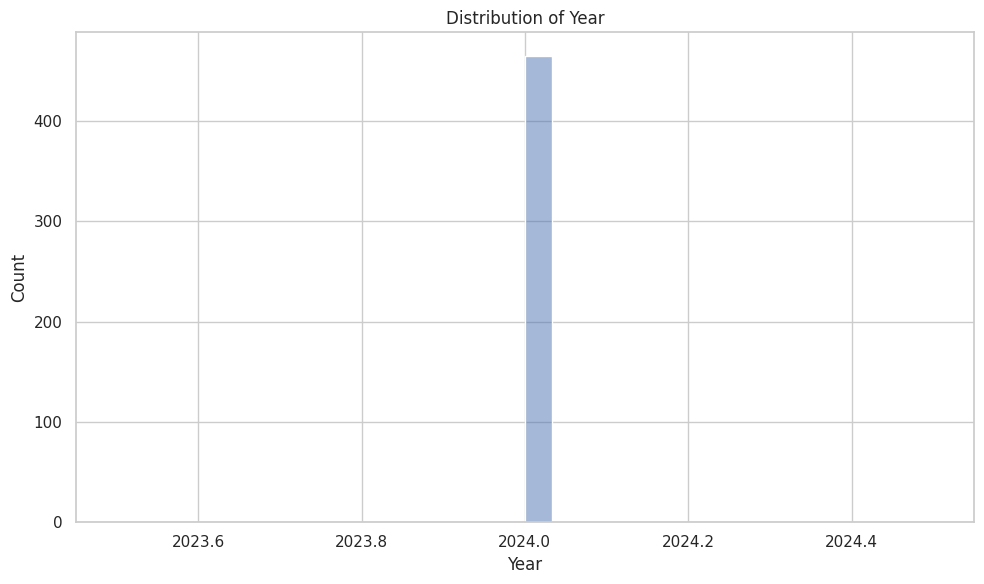

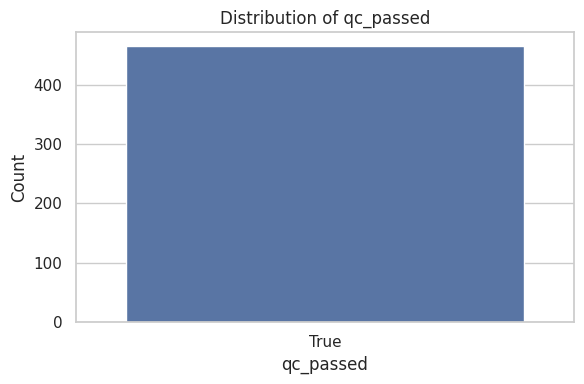

In [7]:
# Visualizations to understand the distribution and relationships within the data
plt.figure(figsize=(10, 6))
sns.histplot(df['year'], kde=True, bins=30)
plt.title('Distribution of Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Count plot for qc_passed to check the balance in the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='qc_passed', data=df)
plt.title('Distribution of qc_passed')
plt.xlabel('qc_passed')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Correlation heatmap for numeric features (only if there are 4 or more numeric columns)
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 10))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()

# Pair Plot: Visualizing pairwise relationships between a subset of numeric features
sample_cols = ['rscore', 'learning_rate', 'batch_size', 'epochs']
if all(col in df.columns for col in sample_cols):
    sns.pairplot(df[sample_cols])
    plt.show()

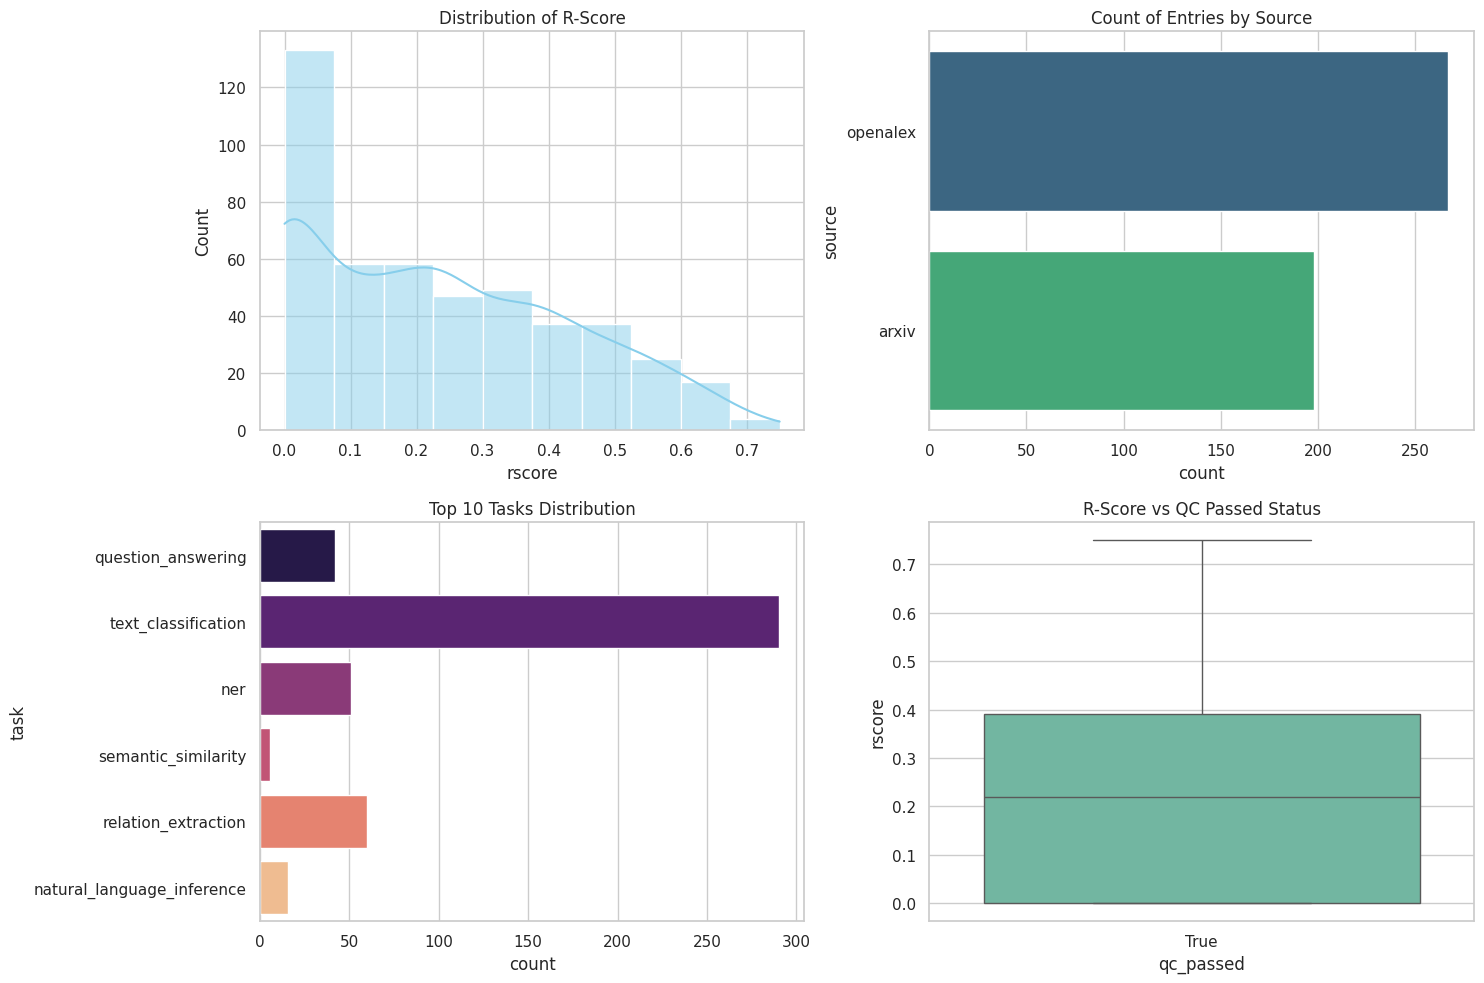

In [8]:
plt.figure(figsize=(15, 10))

# 1. Distribution of rscore
plt.subplot(2, 2, 1)
sns.histplot(df['rscore'], kde=True, color='skyblue')
plt.title('Distribution of R-Score')

# 2. Count by Source
plt.subplot(2, 2, 2)
sns.countplot(y='source', data=df, palette='viridis')
plt.title('Count of Entries by Source')

# 3. Count by Task
plt.subplot(2, 2, 3)
# Selecting top 10 tasks if there are many to keep the plot readable
top_tasks = df['task'].value_counts().nlargest(10).index
sns.countplot(y='task', data=df[df['task'].isin(top_tasks)], palette='magma')
plt.title('Top 10 Tasks Distribution')

# 4. Boxplot of rscore by qc_passed
plt.subplot(2, 2, 4)
sns.boxplot(x='qc_passed', y='rscore', data=df, palette='Set2')
plt.title('R-Score vs QC Passed Status')

plt.tight_layout()
plt.show()

# **Predictive Modeling**

In [9]:
# Predictive Modeling: Forecasting qc_passed from hyperparameters
print('Starting predictive modeling to forecast qc_passed from hyperparameters')

# Convert the boolean target 'qc_passed' to an integer representation (True->1, False->0)
df['qc_passed'] = df['qc_passed'].astype(int)

# Check the distribution of the target variable
target_distribution = df['qc_passed'].value_counts()
print('Target distribution:\n', target_distribution)

# Ensure there are at least two classes for modeling
if df['qc_passed'].nunique() < 2:
    print('Not enough classes to build a predictive model. Found only one class in qc_passed.')
else:
    # Define our feature set with a subset of numeric hyperparameters
    feature_cols = ['rscore', 'learning_rate', 'batch_size', 'epochs', 'max_seq_length',
                    'weight_decay', 'dropout', 'warmup_steps', 'warmup_ratio', 'gradient_clipping', 'seed']

    # Check if these columns exist
    missing_features = [col for col in feature_cols if col not in df.columns]
    if missing_features:
        sys.exit(f'The following required feature columns are missing: {missing_features}')

    # Extract features and target
    X = df[feature_cols]
    y = df['qc_passed']

    # In case of any persisting missing values in features, apply imputation
    if X.isnull().any().any():
        print('Found remaining NaN values in features; applying imputation again.')
        X = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(X), columns=feature_cols)

    # Splitting the data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

    # Feature scaling to expedite model convergence
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Logistic Regression Model (a simple yet effective choice for binary classification)
    model = LogisticRegression(max_iter=1000, random_state=42)
    try:
        model.fit(X_train_scaled, y_train)
    except ValueError as ve:
        sys.exit(f'Error during model fitting: {ve}')

    # Predictions and accuracy score
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f'Accuracy Score: {acc:.2f}')

    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # ROC Curve
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # Permutation Importance using model coefficients (a dry but effective measure)
    importance = model.coef_[0]
    indices = np.argsort(importance)[::-1]

    plt.figure(figsize=(8, 5))
    plt.barh(range(len(indices)), importance[indices], align='center')
    plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
    plt.xlabel('Coefficient Value')
    plt.title('Feature Importance based on Coefficients')
    plt.tight_layout()
    plt.show()

Starting predictive modeling to forecast qc_passed from hyperparameters
Target distribution:
 qc_passed
1    465
Name: count, dtype: int64
Not enough classes to build a predictive model. Found only one class in qc_passed.


# **Discussion and Future Work**


In this notebook, we explored hyperparameter data from a BERT fine-tuning task. Our analysis began by cleaning and exploring the data, followed by a series of visualizations to understand distributions and relationships. The predictive modeling section aimed to forecast the quality control status ('qc_passed') based on various hyperparameters.

A notable challenge arose when the target variable lacked sufficient class diversity. In such cases, it is essential to check the target distribution before modeling to avoid errors similar to the one encountered.

Future work might include:

Exploring additional features or transformations for improved prediction.
Trying alternative modeling methods (e.g., tree-based models) and validating them through cross-validation.
Analyzing the impact of interactions between hyperparameters using more advanced techniques such as Partial Dependence Plots (PDP) or SHAP values.
If this notebook provided useful insights or techniques, please consider upvoting it.